<a href="https://colab.research.google.com/github/VSUrhuel/forage-classifications/blob/main/Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from google.colab import drive
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as eff_preprocess
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mnv_preprocess
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
TEST_DIR = '/content/drive/MyDrive/Undergrad Thesis/Dataset/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CONFIDENCE_THRESHOLD = 0.60  # Safety threshold for "Unknown

In [6]:
models_to_test = [
    {
        'name': 'EfficientNetV2',
        'path': '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/efficientnetv2_finetuned_ver2.keras',
        'preprocessing': eff_preprocess # Uses internal scaling
    },
    {
        'name': 'MobileNetV3',
        'path': '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/mobilenetv3_finetuned_ver2.keras',
        'preprocessing': mnv_preprocess # Uses internal scaling
    },
    {
        'name': 'Progressive EfficientNetV2',
        'path': '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/efficientnetv2_progressive.keras',
        'preprocessing': eff_preprocess # Uses internal scaling
    },
    {
        'name': 'Progressive MobileNetV3',
        'path': '/content/drive/MyDrive/Undergrad Thesis/Dataset/Models/mobilenetv3_progressive.keras',
        'preprocessing': mnv_preprocess # Uses internal scaling
    },
]

In [7]:
def evaluate_model_performance(model_info):
    print(f"\n{'='*40}")
    print(f"Testing Model: {model_info['name']}")
    print(f"{'='*40}")

    # A. Setup Test Generator
    if model_info.get('rescale'):
        test_datagen = ImageDataGenerator(rescale=model_info['rescale'])
    else:
        test_datagen = ImageDataGenerator(preprocessing_function=model_info['preprocessing'])

    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    # B. Load Model & Measure Size
    model = load_model(model_info['path'])
    file_size = os.path.getsize(model_info['path']) / (1024 * 1024) # Convert to MB
    print(f"Model Size: {file_size:.2f} MB")

    # C. Measure Inference Time (Latency)
    # Run a "warm-up" first

    dummy_input = np.random.rand(1, 224, 224, 3).astype(np.float32)
    _ = model.predict(dummy_input, verbose=0)

    # Measure average time per image over the test set
    start_time = time.time()
    predictions_raw = model.predict(test_generator, verbose=1)
    end_time = time.time()

    total_time = end_time - start_time
    avg_inference_time = (total_time / test_generator.samples) * 1000 # Convert to ms
    print(f"Avg Inference Speed: {avg_inference_time:.2f} ms/image (on current GPU)")

    # D. Process Predictions
    predicted_indices = np.argmax(predictions_raw, axis=1)
    max_confidences = np.max(predictions_raw, axis=1)
    true_classes = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())

    # --- SAFETY CHECK: Unknown Class Analysis ---
    # Count how many images fell below the confidence threshold
    uncertain_count = np.sum(max_confidences < CONFIDENCE_THRESHOLD)
    print(f"\n[Safety Check] Low Confidence Detections (<{CONFIDENCE_THRESHOLD*100}%): {uncertain_count}/{len(true_classes)}")

    # E. Calculate Metrics
    acc = accuracy_score(true_classes, predicted_indices)
    prec = precision_score(true_classes, predicted_indices, average='macro', zero_division=0)
    rec = recall_score(true_classes, predicted_indices, average='macro', zero_division=0)
    f1 = f1_score(true_classes, predicted_indices, average='macro', zero_division=0)

    # Calculate Specificity (Macro Average)
    # Specificity = TN / (TN + FP)
    cm = confusion_matrix(true_classes, predicted_indices)
    specificities = []
    for i in range(len(cm)):
        tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i, i])
        fp = np.sum(cm[:, i]) - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(specificity)
    macro_specificity = np.mean(specificities)

    print(f"\n--- PERFORMANCE METRICS ({model_info['name']}) ---")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Precision:   {prec:.4f} (Macro)")
    print(f"Recall:      {rec:.4f} (Macro)")
    print(f"Specificity: {macro_specificity:.4f} (Macro)")
    print(f"F1 Score:    {f1:.4f} (Macro)")

    # F. Generate Confusion Matrix Plot
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_info["name"]}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return {
        'Model': model_info['name'],
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'Specificity': macro_specificity,
        'Inference Time (ms)': avg_inference_time,
        'Model Size (MB)': file_size
    }


Testing Model: EfficientNetV2
Found 781 images belonging to 14 classes.
Model Size: 47.30 MB


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 262s 10s/step
Avg Inference Speed: 357.93 ms/image (on current GPU)

[Safety Check] Low Confidence Detections (<60.0%): 23/781

--- PERFORMANCE METRICS (EfficientNetV2) ---
Accuracy:    0.9552
Precision:   0.9572 (Macro)
Recall:      0.9552 (Macro)
Specificity: 0.9966 (Macro)
F1 Score:    0.9555 (Macro)


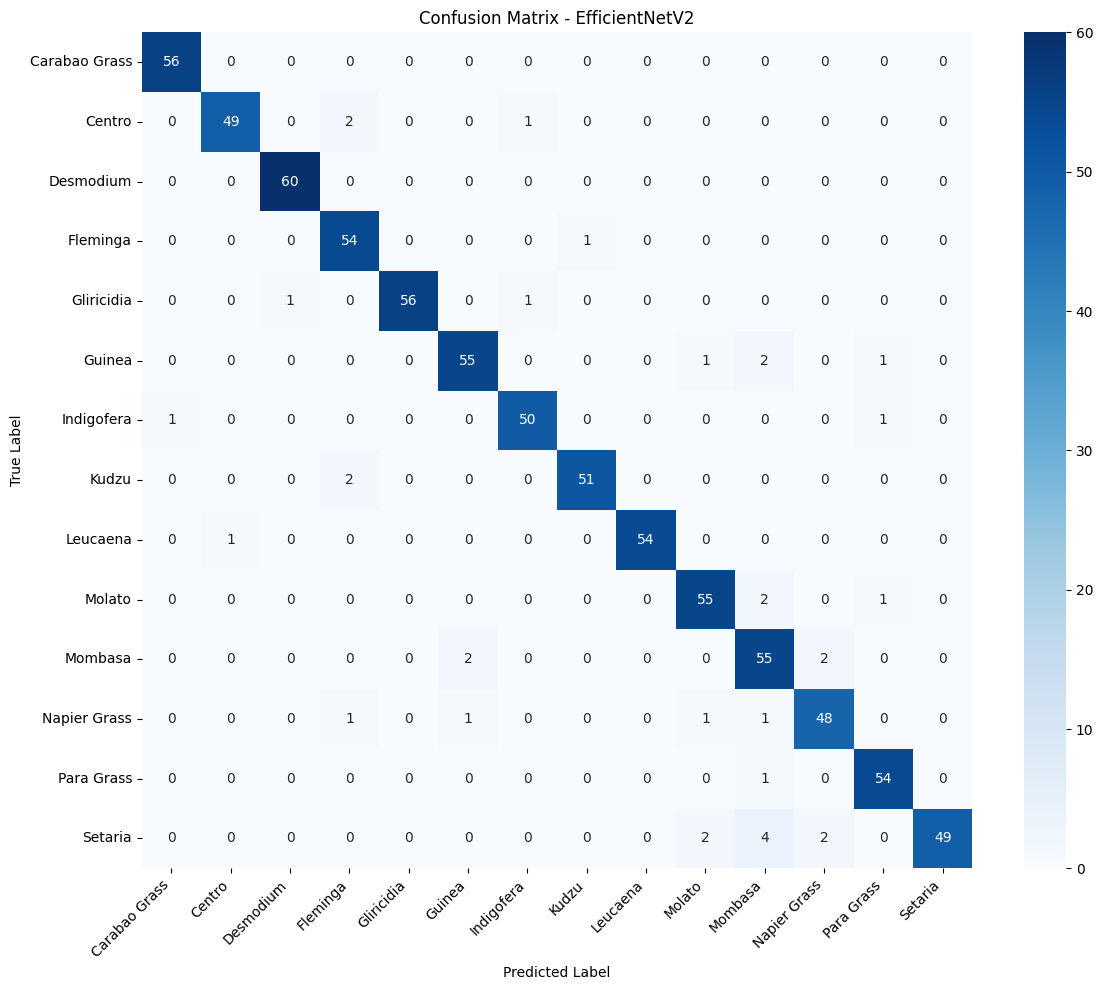


Testing Model: MobileNetV3
Found 781 images belonging to 14 classes.
Model Size: 14.98 MB


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 292s 11s/step
Avg Inference Speed: 375.00 ms/image (on current GPU)

[Safety Check] Low Confidence Detections (<60.0%): 102/781

--- PERFORMANCE METRICS (MobileNetV3) ---
Accuracy:    0.9129
Precision:   0.9141 (Macro)
Recall:      0.9133 (Macro)
Specificity: 0.9933 (Macro)
F1 Score:    0.9133 (Macro)


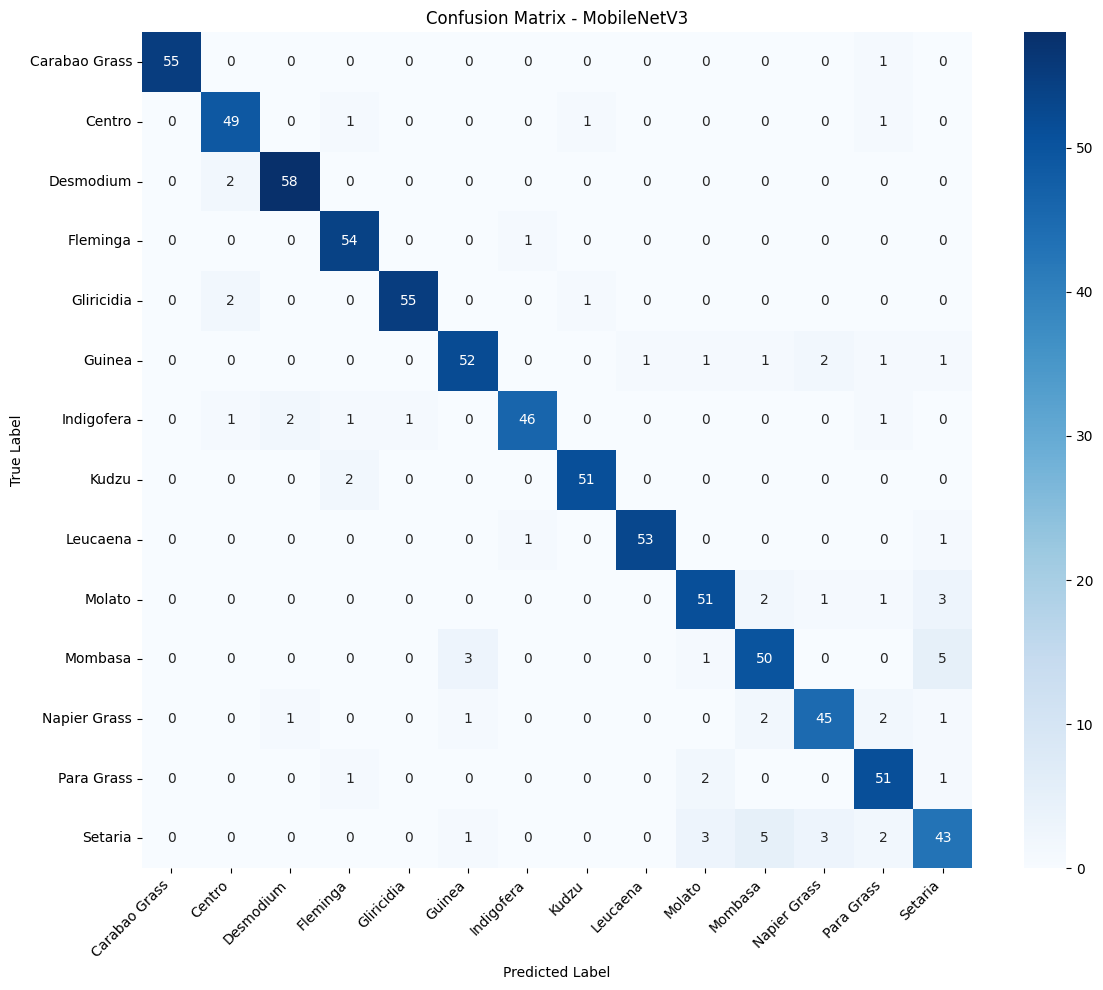


Testing Model: Progressive EfficientNetV2
Found 781 images belonging to 14 classes.
Model Size: 62.88 MB


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 267s 10s/step
Avg Inference Speed: 342.26 ms/image (on current GPU)

[Safety Check] Low Confidence Detections (<60.0%): 15/781

--- PERFORMANCE METRICS (Progressive EfficientNetV2) ---
Accuracy:    0.9744
Precision:   0.9744 (Macro)
Recall:      0.9745 (Macro)
Specificity: 0.9980 (Macro)
F1 Score:    0.9743 (Macro)


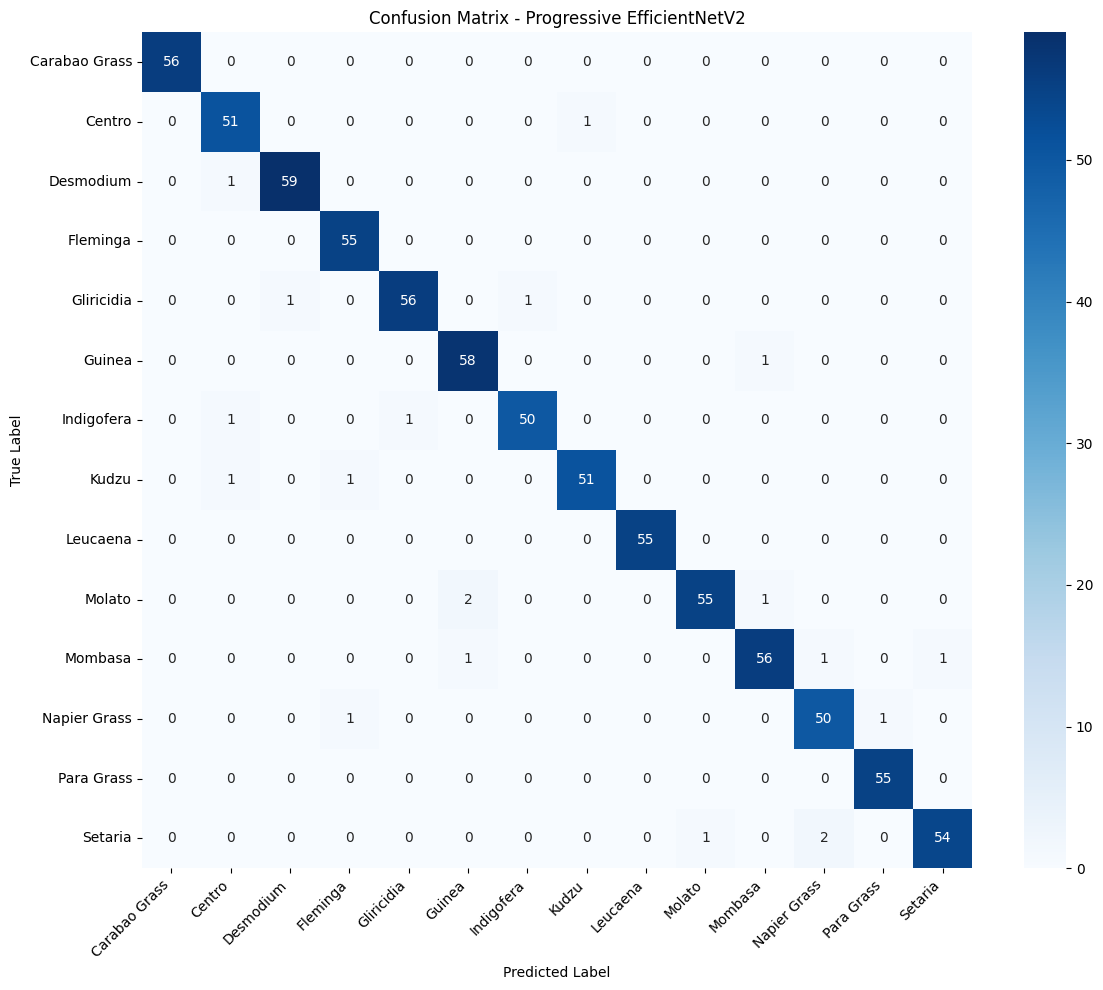


Testing Model: Progressive MobileNetV3
Found 781 images belonging to 14 classes.
Model Size: 40.52 MB


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


25/25 ━━━━━━━━━━━━━━━━━━━━ 332s 13s/step
Avg Inference Speed: 425.07 ms/image (on current GPU)

[Safety Check] Low Confidence Detections (<60.0%): 18/781

--- PERFORMANCE METRICS (Progressive MobileNetV3) ---
Accuracy:    0.9590
Precision:   0.9620 (Macro)
Recall:      0.9585 (Macro)
Specificity: 0.9968 (Macro)
F1 Score:    0.9589 (Macro)


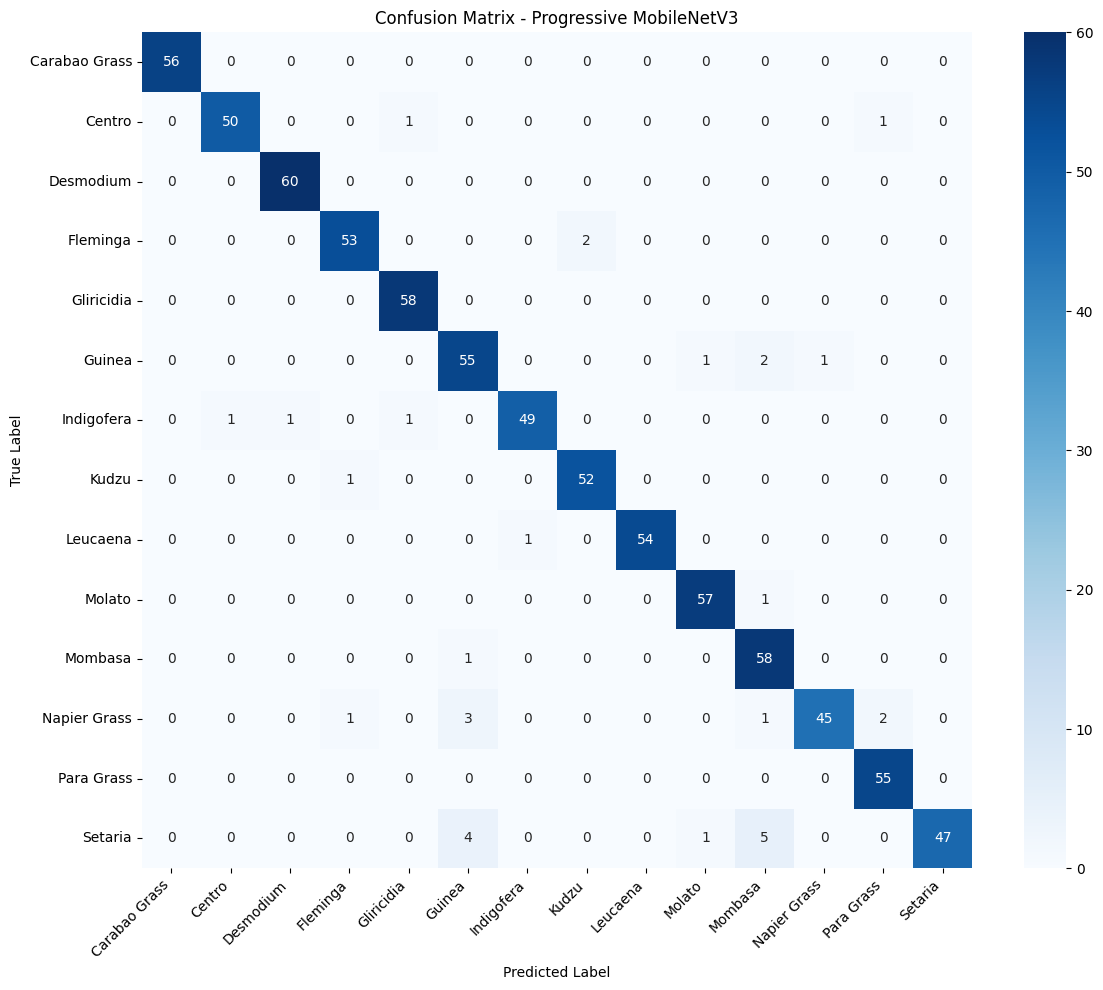



FINAL COMPARISON SUMMARY
Model           | Acc      | F1       | Speed(ms)  | Size(MB)  
------------------------------------------------------------
EfficientNetV2  | 0.9552   | 0.9555   | 357.93     | 47.30     
MobileNetV3     | 0.9129   | 0.9133   | 375.00     | 14.98     
Progressive EfficientNetV2 | 0.9744   | 0.9743   | 342.26     | 62.88     
Progressive MobileNetV3 | 0.9590   | 0.9589   | 425.07     | 40.52     


In [8]:
results = []
for m in models_to_test:
    res = evaluate_model_performance(m)
    results.append(res)

# --- 4. PRINT SUMMARY TABLE ---
print("\n\n" + "="*60)
print("FINAL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<15} | {'Acc':<8} | {'F1':<8} | {'Speed(ms)':<10} | {'Size(MB)':<10}")
print("-" * 60)
for r in results:
    print(f"{r['Model']:<15} | {r['Accuracy']:.4f}   | {r['F1 Score']:.4f}   | {r['Inference Time (ms)']:<10.2f} | {r['Model Size (MB)']:<10.2f}")